In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Mois"] = df["Order Date"].dt.month

ventes_mois = df.groupby("Mois")["Sales"].sum()

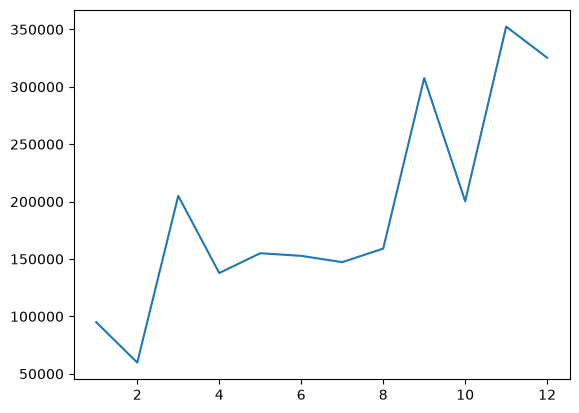

In [2]:
plt.plot(ventes_mois.index, ventes_mois.values)
plt.show()

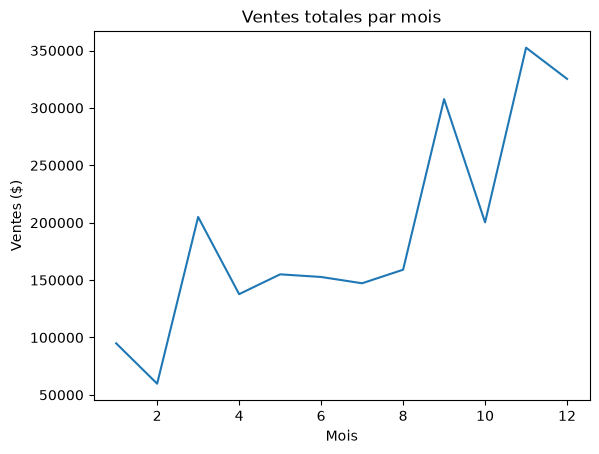

In [3]:
plt.plot(ventes_mois.index, ventes_mois.values)
plt.title("Ventes totales par mois")
plt.xlabel("Mois")
plt.ylabel("Ventes ($)")
plt.show()

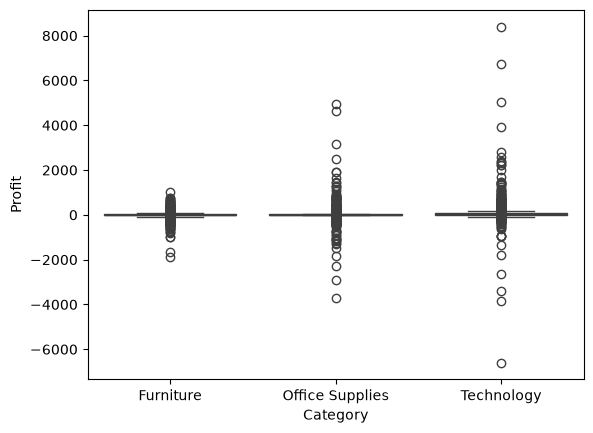

In [4]:
import seaborn as sns

sns.boxplot(data=df, x="Category", y="Profit")
plt.show()

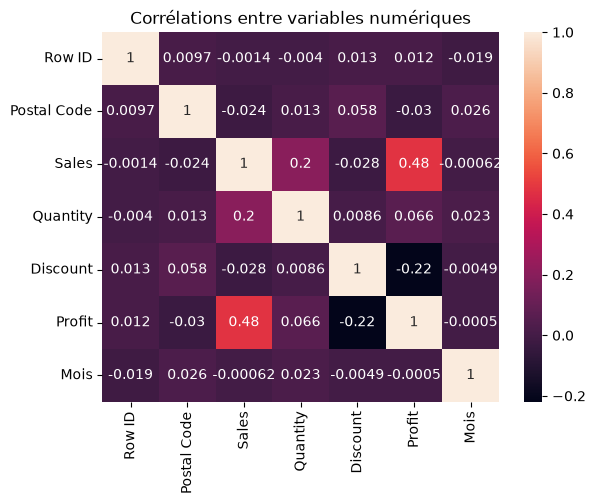

In [5]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Corrélations entre variables numériques")
plt.show()

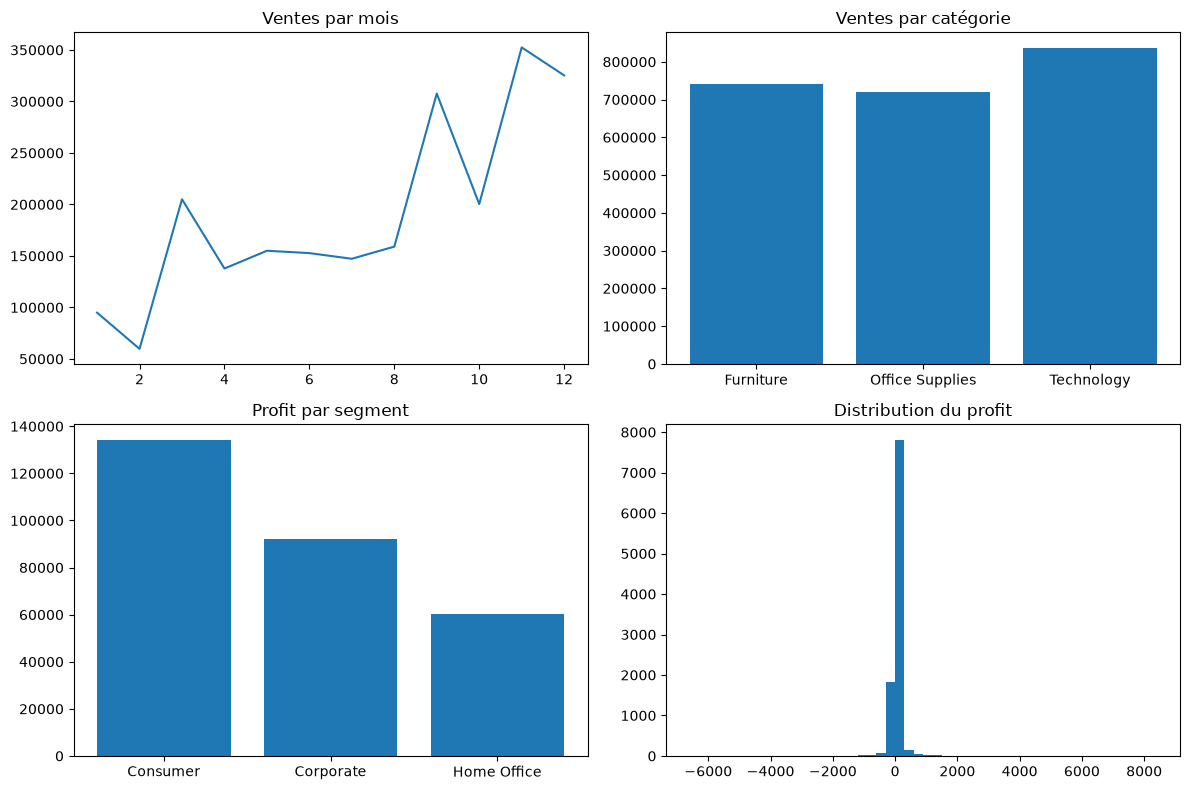

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Graphique 1 : ventes par mois
axes[0, 0].plot(ventes_mois.index, ventes_mois.values)
axes[0, 0].set_title("Ventes par mois")

# Graphique 2 : ventes par catégorie
ventes_cat = df.groupby("Category")["Sales"].sum()
axes[0, 1].bar(ventes_cat.index, ventes_cat.values)
axes[0, 1].set_title("Ventes par catégorie")

# Graphique 3 : profit par segment
profit_seg = df.groupby("Segment")["Profit"].sum()
axes[1, 0].bar(profit_seg.index, profit_seg.values)
axes[1, 0].set_title("Profit par segment")

# Graphique 4 : distribution du profit
axes[1, 1].hist(df["Profit"], bins=50)
axes[1, 1].set_title("Distribution du profit")

plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_happy = pd.read_csv("2015.csv")
df_happy.head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


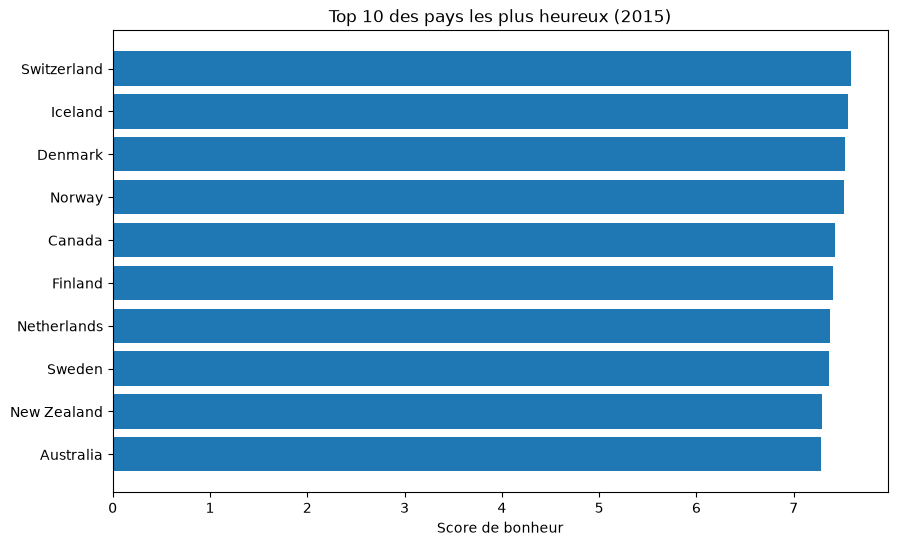

In [8]:
# On prend les 10 premiers pays (déjà triés par score de bonheur)
top10 = df_happy.head(10)

# On crée une feuille blanche de taille 10x6
plt.figure(figsize=(10, 6))

# On dessine les barres horizontales
# Axe Y = noms des pays, Axe X = score de bonheur
plt.barh(top10["Country"], top10["Happiness Score"])

# On ajoute le label de l'axe horizontal
plt.xlabel("Score de bonheur")

# On ajoute le titre du graphique
plt.title("Top 10 des pays les plus heureux (2015)")

# On retourne l'axe Y pour que le pays n°1 soit en haut
plt.gca().invert_yaxis()

# On affiche le graphique
plt.show()

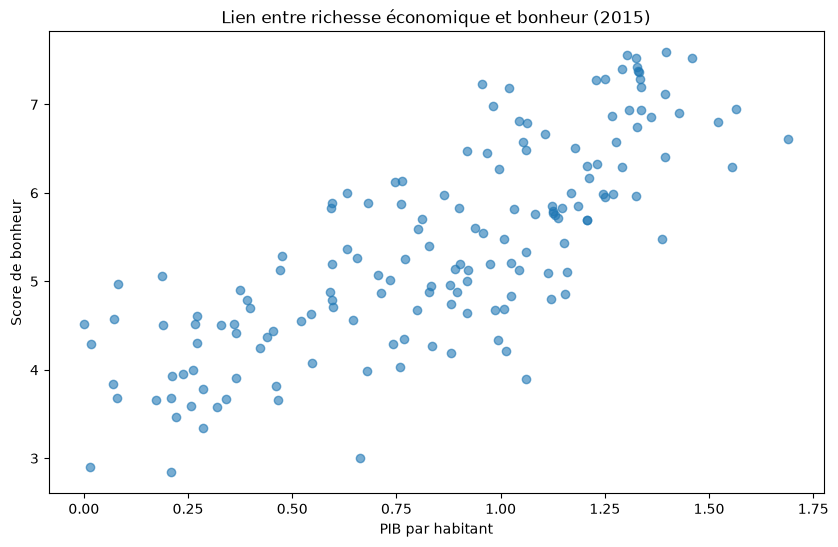

In [9]:
# On crée la figure
plt.figure(figsize=(10, 6))

# On trace le scatter plot
# Axe X = richesse économique (PIB), Axe Y = score de bonheur
# Chaque point = un pays
plt.scatter(df_happy["Economy (GDP per Capita)"], 
            df_happy["Happiness Score"],
            alpha=0.6)  # alpha = transparence des points (0=invisible, 1=opaque)

# On ajoute les labels et le titre
plt.xlabel("PIB par habitant")
plt.ylabel("Score de bonheur")
plt.title("Lien entre richesse économique et bonheur (2015)")

# On affiche
plt.show()

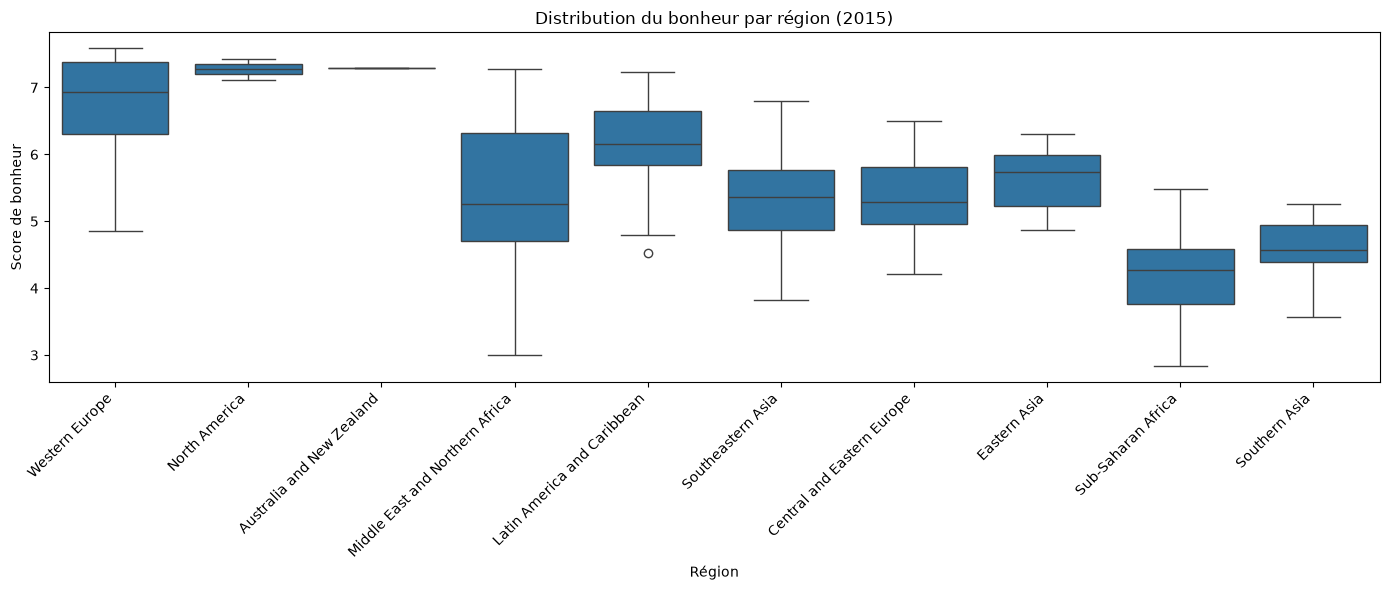

In [10]:
# On crée une grande figure pour que les noms de régions soient lisibles
plt.figure(figsize=(14, 6))

# Boxplot : distribution du bonheur pour chaque région du monde
sns.boxplot(data=df_happy, x="Region", y="Happiness Score")

# On tourne les étiquettes de l'axe X à 45° pour éviter qu'elles se chevauchent
plt.xticks(rotation=45, ha="right")

# Labels et titre
plt.title("Distribution du bonheur par région (2015)")
plt.xlabel("Région")
plt.ylabel("Score de bonheur")

# On ajuste automatiquement les marges pour que rien ne soit coupé
plt.tight_layout()
plt.show()

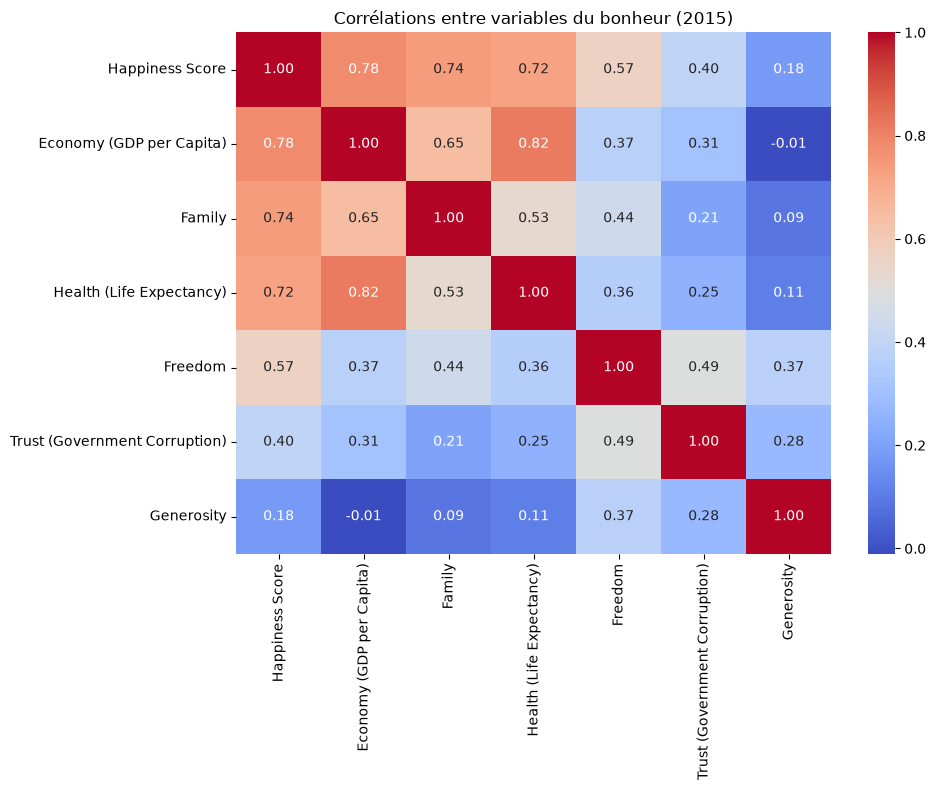

In [11]:
# On sélectionne uniquement les colonnes numériques utiles
cols_numeriques = ["Happiness Score", "Economy (GDP per Capita)", 
                   "Family", "Health (Life Expectancy)", 
                   "Freedom", "Trust (Government Corruption)", 
                   "Generosity"]

# On calcule les corrélations
plt.figure(figsize=(10, 8))

# On trace la heatmap avec les chiffres affichés (annot=True)
# fmt=".2f" = afficher 2 décimales
sns.heatmap(df_happy[cols_numeriques].corr(), 
            annot=True, 
            fmt=".2f",
            cmap="coolwarm")  # coolwarm = bleu (négatif) → rouge (positif)

plt.title("Corrélations entre variables du bonheur (2015)")
plt.tight_layout()
plt.show()

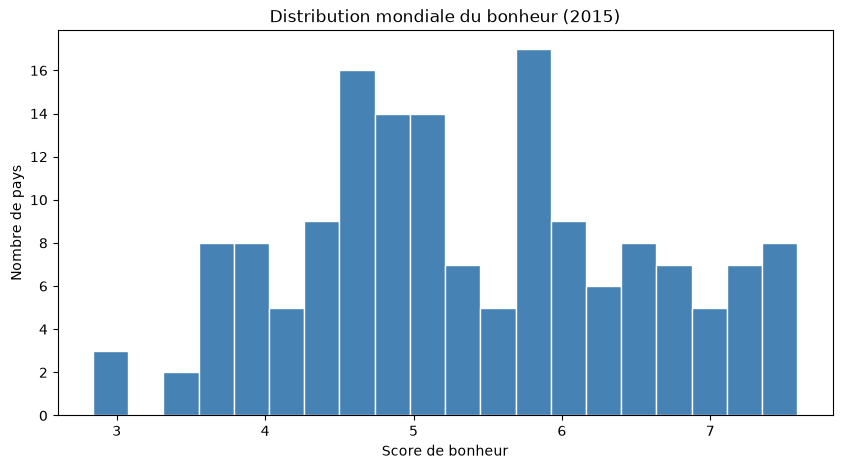

In [12]:
# Graphique 5 : Distribution globale du score de bonheur
plt.figure(figsize=(10, 5))

# bins=20 = découper en 20 intervalles
# color et edgecolor = couleurs des barres et de leurs contours
plt.hist(df_happy["Happiness Score"], bins=20, 
         color="steelblue", edgecolor="white")

plt.xlabel("Score de bonheur")
plt.ylabel("Nombre de pays")
plt.title("Distribution mondiale du bonheur (2015)")
plt.show()

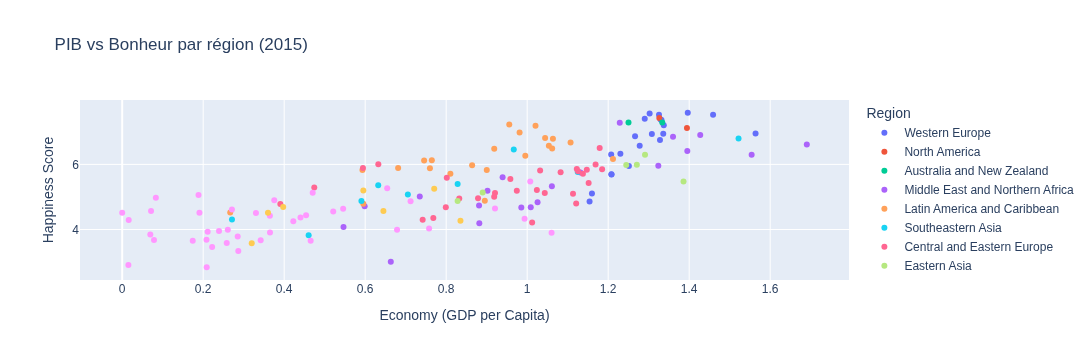

In [13]:
# Graphique 6 : Scatter interactif Plotly — PIB vs Bonheur, coloré par région
import plotly.express as px

fig = px.scatter(df_happy,
                 x="Economy (GDP per Capita)",
                 y="Happiness Score",
                 color="Region",        # chaque région a une couleur différente
                 hover_name="Country",  # survole un point → nom du pays affiché
                 title="PIB vs Bonheur par région (2015)")
fig.show()

In [16]:
# ---- Export 1 : Top 10 pays les plus heureux ----
top10 = df_happy.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top10["Country"], top10["Happiness Score"])
plt.xlabel("Score de bonheur")
plt.title("Top 10 des pays les plus heureux (2015)")
plt.gca().invert_yaxis()
plt.savefig("01_top10_bonheur.png", dpi=150, bbox_inches="tight")
plt.close()  # ferme la figure pour libérer la mémoire

# ---- Export 2 : Scatter PIB vs Bonheur ----
plt.figure(figsize=(10, 6))
plt.scatter(df_happy["Economy (GDP per Capita)"], 
            df_happy["Happiness Score"], alpha=0.6)
plt.xlabel("PIB par habitant")
plt.ylabel("Score de bonheur")
plt.title("Lien entre richesse économique et bonheur (2015)")
plt.savefig("02_pib_vs_bonheur.png", dpi=150, bbox_inches="tight")
plt.close()

# ---- Export 3 : Boxplot par région ----
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_happy, x="Region", y="Happiness Score")
plt.xticks(rotation=45, ha="right")
plt.title("Distribution du bonheur par région (2015)")
plt.xlabel("Région")
plt.ylabel("Score de bonheur")
plt.tight_layout()
plt.savefig("03_boxplot_regions.png", dpi=150, bbox_inches="tight")
plt.close()

# ---- Export 4 : Heatmap corrélations ----
cols_numeriques = ["Happiness Score", "Economy (GDP per Capita)", 
                   "Family", "Health (Life Expectancy)", 
                   "Freedom", "Trust (Government Corruption)", 
                   "Generosity"]
plt.figure(figsize=(10, 8))
sns.heatmap(df_happy[cols_numeriques].corr(), 
            annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Corrélations entre variables du bonheur (2015)")
plt.tight_layout()
plt.savefig("04_heatmap_correlations.png", dpi=150, bbox_inches="tight")
plt.close()

# ---- Export 5 : Histogramme distribution ----
plt.figure(figsize=(10, 5))
plt.hist(df_happy["Happiness Score"], bins=20, 
         color="steelblue", edgecolor="white")
plt.xlabel("Score de bonheur")
plt.ylabel("Nombre de pays")
plt.title("Distribution mondiale du bonheur (2015)")
plt.savefig("05_histogramme_bonheur.png", dpi=150, bbox_inches="tight")
plt.close()

# ---- Export 6 : Plotly interactif en HTML ----
fig = px.scatter(df_happy,
                 x="Economy (GDP per Capita)",
                 y="Happiness Score",
                 color="Region",
                 hover_name="Country",
                 title="PIB vs Bonheur par région (2015)")
fig.write_html("06_bonheur_interactif.html")

print(" 6 fichiers exportés avec succès !")

 6 fichiers exportés avec succès !
